In [1]:
import os
import sys
import io
import ctypes
import json
from ctypes import *
import numpy as np
import numpy.ctypeslib
from PIL import Image

from utils import plot_accuracies, plot_losses, load_json
from dataset import load_image, load_dataset, shuffle_dataset, z_normalize, display_images

from lib_loader import load_my_lib

seed = 42

2024-07-23 18:50:41.373991: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-23 18:50:41.407532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-23 18:50:41.882130: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


X_train shape: (14763, 48, 48, 3)
y_train shape: (14763, 3)
X_test shape: (3700, 48, 48, 3)
y_test shape: (3700, 3)


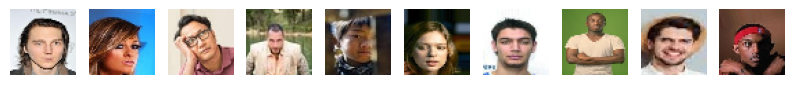

In [2]:
# Charger le dataset
image_size = 48  # Taille des images
dataset_path = '../dataset_upgrade'
X_train, y_train, X_test, y_test = load_dataset(dataset_path, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train)
X_test, y_test = shuffle_dataset(X_test, y_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

display_images(X_train, 10)

In [2]:
path = "../my_lib/target/release/deps/libmy_lib.so"

lib = load_my_lib(path)

In [ ]:
# Normaliser les données
X_train_normalized, X_test_normalized = z_normalize(X_train, X_test)

# Aplatir les images pour MLP
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)

# Paramètres
num_samples, input_dim = X_train_flat.shape
output_dim = y_train.shape[1]
y_dim = 1
gamma = 1.0
k = len(X_train)
seed = 42

# Créer un modèle RBF
rbf_model = lib.create_MyRBF(X_train, k, input_dim, y_dim, gamma, seed)

# Entraîner le modèle RBF
lib.train_MyRBF(
    rbf_model,
    X_train_flat,
    y_train,
    X_test_flat,
    y_test,
    num_samples,
    num_samples,
    input_dim,
    output_dim,
    0.1,
    10,
    True
)

In [4]:
lib_path = "../my_lib/target/release/deps/libmy_lib.so"
my_lib = load_my_lib(lib_path)

# Données d'exemple
X_train = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
], dtype=np.float64)

y_train = np.array([
    [-1.0],
    [1.0],
    [1.0],
    [-1.0]
], dtype=np.float64)

X_test = X_train
y_test = y_train

# Paramètres
num_samples, input_dim = X_train.shape
output_dim = y_train.shape[1]
y_dim = 1
gamma = 1.0
k = len(X_train)
seed = 42

# Exécuter KMeans pour obtenir les centres
# centers_ptr = my_lib.kmeans(X_train, num_samples, input_dim, k, seed)
centers_ptr = X_train
centers = np.ctypeslib.as_array(centers_ptr, shape=(k, input_dim))

# Créer un modèle RBF
rbf_model = my_lib.create_MyRBF(X_train, k, input_dim, y_dim, gamma, seed)

# Entraîner le modèle RBF
my_lib.train_MyRBF(
    rbf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    num_samples,
    num_samples,
    input_dim,
    output_dim,
    0.1,
    1000,
    True
)

# Faire des prédictions
predictions_ptr = my_lib.predict_MyRBF(rbf_model, X_test, num_samples, input_dim, True)
predictions = np.ctypeslib.as_array(predictions_ptr, shape=(num_samples, y_dim))

print("Predictions:", predictions)

# Libérer la mémoire
my_lib.destroy_MyRBF(rbf_model)

Training starting...
Epoch 0: Train Loss: 3.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 1: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 2: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 3: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 4: Train Loss: 2.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 5: Train Loss: 1.0000, Test Loss: 1.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 6: Train Loss: 3.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 7: Train Loss: 1.0000, Test Loss: 1.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 8: Train Loss: 3.0000, Test Loss: 2.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 9: Train Loss: 1.0000, Test Loss: 1.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 10: Train Loss: 2.0000, Test Loss: 1.0000, Train Acc: 100.0%, Test Acc: 100.0%
Epoch 11: Train Loss: 3.0000, Test Loss: 1.0000, Train

0

In [3]:
import matplotlib.pyplot as plt